In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

# Inisialisasi spark

In [ ]:
!pip install pyspark -q

# 2. Import Library Utama
import os
import tensorflow as tf
from pyspark.sql import SparkSession

# 3. Verifikasi Akselerasi GPU
print("Daftar Perangkat Fisik GPU:")
print(tf.config.list_physical_devices('GPU'))
print("-" * 40)

# 4. Inisialisasi Apache Spark dengan Konfigurasi Teruji (Anti-OOM)
print("Menginisialisasi Spark Session (Alokasi Terkendali Sesuai Skenario 2W)...")

spark = SparkSession.builder \
    .appName("SkinCancer_BigData_Irisan3Kelas") \
    .config("spark.executor.instances", "2") \
    .config("spark.executor.cores", "1") \
    .config("spark.executor.memory", "1536m") \
    .config("spark.executor.memoryOverhead", "384m") \
    .config("spark.driver.memory", "2g") \
    .config("spark.driver.maxResultSize", "1g") \
    .getOrCreate()

print("Spark Session Berhasil Dibuat (Alokasi Aman ~4 GB RAM)!")

2026-06-13 02:31:43.239549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781317903.415599      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781317903.465249      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781317903.881181      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781317903.881218      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781317903.881221      58 computation_placer.cc:177] computation placer alr

Daftar Perangkat Fisik GPU:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
----------------------------------------
Menginisialisasi Spark Session...


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/13 02:32:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Session Berhasil Dibuat!


# Load dataset

In [ ]:
import os
import time
import glob
import warnings
import pandas as pd
from pathlib import Path
from pyspark.sql.functions import col, when
from pyspark import TaskContext

warnings.filterwarnings('ignore')
spark.sparkContext.setLogLevel("ERROR")

print("[INFO] Memproses Dataset Riset Irisan 3 Kelas (HAM10000 + ISIC 2019 + ISIC 2017)...")

# 1. Pencarian File Manifest Master Irisan 3 Kelas
csv_candidates = [
    Path("/kaggle/input/dataset-irisan-multiclass-final/dataset_irisan_multiclass_final.csv"),
    Path("/kaggle/input/dataset_irisan_multiclass_final.csv"),
    Path("Dataset/csv_irisan_3kelas/dataset_irisan_multiclass_final.csv"),
    Path("Dataset/dataset_irisan_multiclass_final.csv"),
    Path("/kaggle/working/dataset_irisan_multiclass_final.csv")
]

csv_path = None
for candidate in csv_candidates:
    if candidate.exists():
        csv_path = str(candidate)
        break

if not csv_path:
    # Pencarian rekursif jika berada di subfolder Kaggle input
    for root in ["/kaggle/input", "Dataset", "."]:
        if os.path.exists(root):
            matches = glob.glob(f"{root}/**/dataset_irisan_multiclass_final.csv", recursive=True)
            if matches:
                csv_path = matches[0]
                break

# 2. Pemuatan Dataset Menggunakan Apache Spark
if csv_path and os.path.exists(csv_path):
    print(f"[INFO] Memuat manifest irisan dari: {csv_path}")
    spark_df_raw = spark.read.csv(csv_path, header=True, inferSchema=True)
    
    # Harmonisasi label ke 3 nama kelas standar
    spark_df = spark_df_raw.withColumn(
        "label",
        when(col("harmonized_label") == "NV", "nevus")
        .when(col("harmonized_label") == "MEL", "melanoma")
        .when(col("harmonized_label") == "BKL", "seborrheic_keratosis")
        .otherwise("other")
    ).filter(col("label") != "other")
    
    # Pelacakan Waktu Executor Spark untuk Laporan Big Data
    def track_executor_time(iterator):
        start_time = time.time()
        count = sum(1 for _ in iterator)
        elapsed = time.time() - start_time
        ctx = TaskContext.get()
        pid = ctx.partitionId() if ctx else "Unknown"
        yield (pid, count, elapsed)

    metrik_executors = spark_df.rdd.mapPartitions(track_executor_time).collect()
    print("\n=== LAPORAN BEBAN KERJA EXECUTOR SPARK (IRISAN 3 KELAS) ===")
    for pid, count, elapsed in metrik_executors:
        print(f"Executor Task [Partisi {pid}] -> Memproses {count} baris dalam {elapsed:.4f} detik")
    print("============================================================\n")
    
    df_final = spark_df.select("image_id", "label", "source", "filepath").toPandas()
else:
    # Fallback jika CSV master belum diunggah: Ekstraksi langsung dari folder dataset
    print("[WARNING] Manifest CSV tidak ditemukan, memindai direktori gambar Kaggle...")
    ham_meta = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
    if not os.path.exists(ham_meta):
        ham_meta = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
    
    df_ham = pd.read_csv(ham_meta)
    df_ham = df_ham[df_ham['dx'].isin(['nv', 'mel', 'bkl'])].copy()
    label_map = {'nv': 'nevus', 'mel': 'melanoma', 'bkl': 'seborrheic_keratosis'}
    df_ham['label'] = df_ham['dx'].map(label_map)
    df_ham['source'] = 'ham10000'
    df_final = df_ham[['image_id', 'label', 'source']].copy()

# 3. Penyesuaian Path Citra Fisik di Lingkungan Eksekusi (Kaggle / Lokal)
print("[INFO] Mengindeks path citra fisik pada direktori input...")
image_index = {}
search_roots = ["/kaggle/input", "Dataset", "."]

for s_root in search_roots:
    if os.path.exists(s_root):
        for root, _, files in os.walk(s_root):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    stem = os.path.splitext(f)[0]
                    if stem not in image_index:
                        image_index[stem] = os.path.join(root, f)

def resolve_path(row):
    raw_p = str(row.get('filepath', ''))
    if raw_p and os.path.exists(raw_p):
        return raw_p
    img_id = str(row['image_id'])
    if img_id in image_index:
        return image_index[img_id]
    return raw_p

df_final['filepath'] = df_final.apply(resolve_path, axis=1)

# Validasi Keberadaan Berkas Fisik
tersedia = df_final['filepath'].apply(os.path.exists).sum()
print(f"[INFO] Indeks citra siap: {tersedia} dari {len(df_final)} berkas fisik terverifikasi.")

# 4. Tutup Spark Session untuk Melepas Memori RAM ke Sistem
spark.stop()
import gc
gc.collect()
print("[INFO] Spark Session ditutup, seluruh memori RAM dibebaskan untuk tahap pelatihan TensorFlow.")

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Menampilkan Ringkasan Distribusi Data Irisan 3 Kelas
print("=== RINGKASAN DATASET IRISAN (HAM10000 ∩ ISIC 2017 ∩ ISIC 2019) ===")
print(f"Total Citra Terdaftar: {len(df_final)} citra\n")

print("1. Distribusi Berdasarkan Kelas Medis:")
kelas_counts = df_final['label'].value_counts()
for k, v in kelas_counts.items():
    persen = (v / len(df_final)) * 100
    print(f"   - {k:<22}: {v:6d} citra ({persen:.2f}%)")

if 'source' in df_final.columns:
    print("\n2. Distribusi Berdasarkan Sumber Dataset:")
    src_counts = df_final['source'].value_counts()
    for s, v in src_counts.items():
        print(f"   - {s:<22}: {v:6d} citra")

# Visualisasi Distribusi Kelas
plt.figure(figsize=(8, 4))
bars = plt.bar(kelas_counts.index, kelas_counts.values, color=['#2b5c8f', '#d95f02', '#7570b3'])
plt.title("Distribusi Citra Dataset Irisan 3 Kelas (Bebas Duplikat)", fontsize=12)
plt.ylabel("Jumlah Citra")
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 150, f"{yval:,}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

ISIC 2017 Train asli: 2000 gambar

Membaca daftar file dari folder HAM10000...
Selesai! Ditemukan 10015 gambar fisik di folder HAM.

--- RINGKASAN DATASET FINAL ---
Train :  7573 samples (Campuran ISIC 2017 Train + HAM10000)
Val   :   150 samples (100% ISIC 2017 Val Asli)
Test  :   600 samples (100% ISIC 2017 Test Asli)
Total :  8323 samples

Distribusi Kelas di TRAIN (Campuran):
dx
nv     3274
mel    2640
bkl    1659
Name: count, dtype: int64

Rincian Sumber Data di Data Train:
source  HAM10000_Extra  ISIC2017_Train
dx                                    
bkl               1099             560
mel               1113            1527
nv                   0            3274


# preprosesing citra

[INFO] Memulai pemrosesan komplit untuk 16126 gambar...


  0%|          | 0/16126 [00:00<?, ?it/s]

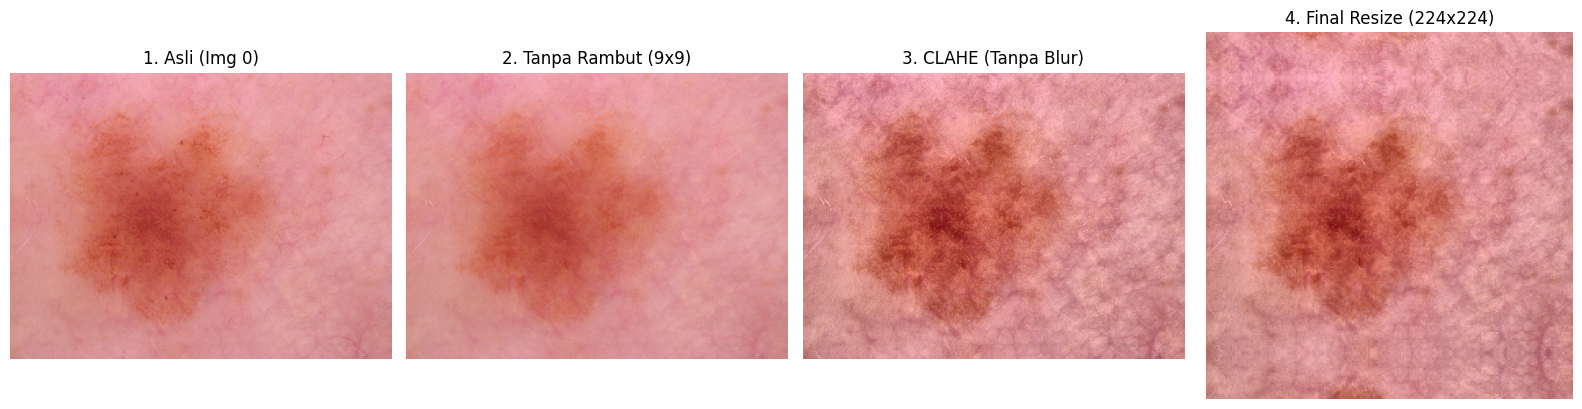

  0%|          | 1/16126 [00:00<3:45:03,  1.19it/s]

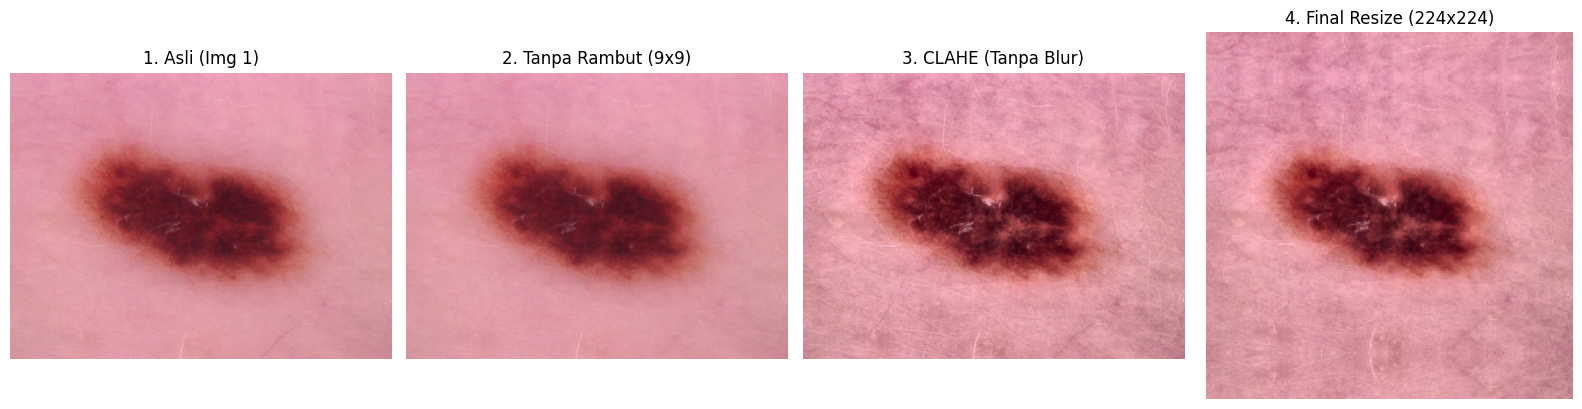

  0%|          | 2/16126 [00:01<2:58:40,  1.50it/s]

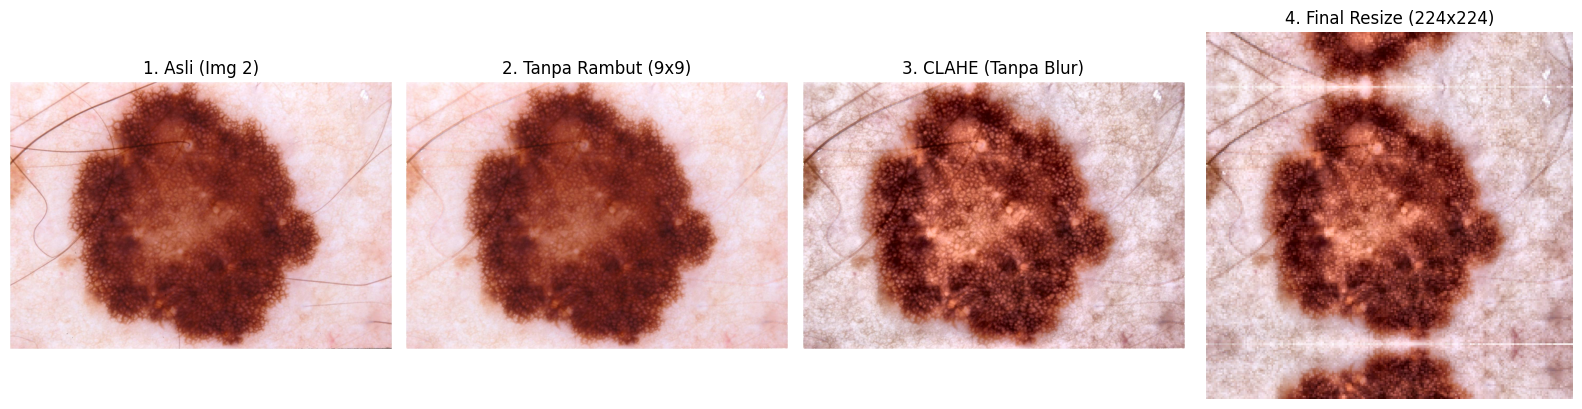

100%|██████████| 16126/16126 [1:04:34<00:00,  4.16it/s]


[INFO] Selesai! Seluruh data gabungan siap dilatih.


In [8]:
# ==========================================
# TAHAP 3: REKAYASA CITRA (FAST MULTI-THREADED PREPROCESSING)
# (RESIZE 299x299, CONTRAST STRETCHING, ACTIVE CONTOUR SEGMENTATION)
# ==========================================
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from skimage.filters import gaussian
from skimage.segmentation import active_contour

def pad_and_resize(img, target_size=299):
    h, w = img.shape[:2]
    max_dim = max(h, w)
    top, bottom = (max_dim - h) // 2, (max_dim - h) - ((max_dim - h) // 2)
    left, right = (max_dim - w) // 2, (max_dim - w) - ((max_dim - w) // 2)
    padded = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_REFLECT)
    return cv2.resize(padded, (target_size, target_size), interpolation=cv2.INTER_AREA)

def contrast_stretching_norm(img, n0=128.0, var0=4000.0):
    img_f = img.astype(np.float32)
    norm_channels = []
    for c in range(3):
        ch = img_f[..., c]
        m = np.mean(ch)
        var = np.var(ch) + 1e-6
        coeff = np.sqrt((var0 * ((ch - m) ** 2)) / var)
        norm_ch = np.where(ch > m, n0 + coeff, n0 - coeff)
        norm_channels.append(norm_ch)
    return np.clip(np.stack(norm_channels, axis=-1), 0, 255).astype(np.uint8)

def active_contour_segmentation(img_rgb, max_iter=15):
    try:
        h, w = img_rgb.shape[:2]
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        smooth_gray = gaussian(gray, sigma=2.0, preserve_range=False)
        
        center_y, center_x = h / 2.0, w / 2.0
        radius_y, radius_x = h * 0.38, w * 0.38
        s = np.linspace(0, 2 * np.pi, 60)
        init_contour = np.array([center_y + radius_y * np.sin(s), center_x + radius_x * np.cos(s)]).T
        
        snake = active_contour(
            smooth_gray,
            init_contour,
            alpha=0.015,
            beta=10.0,
            gamma=0.001,
            max_num_iter=max_iter
        )
        
        mask = np.zeros((h, w), dtype=np.uint8)
        pts = np.int32([np.flip(snake, axis=1)])
        cv2.fillPoly(mask, pts, 255)
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        
        segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
        smoothed = cv2.GaussianBlur(segmented, (3, 3), 0)
        final_segmented = np.where(segmented > 0, smoothed, 0)
        return mask, final_segmented
    except Exception:
        mask = np.ones((img_rgb.shape[0], img_rgb.shape[1]), dtype=np.uint8) * 255
        return mask, img_rgb

def plot_perbandingan(asli, resized, normalized, mask, segmented, index):
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(asli)
    axes[0].set_title(f"1. Asli (Img {index})")
    axes[0].axis('off')
    
    axes[1].imshow(resized)
    axes[1].set_title("2. Resize (299x299)")
    axes[1].axis('off')
    
    axes[2].imshow(normalized)
    axes[2].set_title("3. Normalisasi Kontras")
    axes[2].axis('off')
    
    axes[3].imshow(mask, cmap='gray')
    axes[3].set_title("4. Mask Active Contour")
    axes[3].axis('off')
    
    axes[4].imshow(segmented)
    axes[4].set_title("5. Segmented ROI")
    axes[4].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# OFFLINE PREPROCESSING (MULTI-THREADED PARALEL)
# ==========================================

output_dir = "/kaggle/working/processed_images/"
os.makedirs(output_dir, exist_ok=True)

# 1. Visualisasi 3 Sampel Pertama sebagai Pengecekan Kualitas
print("[INFO] Menampilkan visualisasi 3 sampel citra pertama:")
for index, row in df_final.head(3).iterrows():
    img_bgr = cv2.imread(row['filepath'])
    if img_bgr is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        resized_img = pad_and_resize(img_rgb, target_size=299)
        norm_img = contrast_stretching_norm(resized_img)
        mask, segmented_img = active_contour_segmentation(norm_img)
        plot_perbandingan(img_rgb, resized_img, norm_img, mask, segmented_img, index)

# 2. Fungsi Worker untuk Eksekusi Paralel Multi-Core
def process_single_image(args):
    index, img_path = args
    filename = f"{index}_{os.path.basename(img_path)}"
    new_img_path = os.path.join(output_dir, filename)
    
    # Jika sudah pernah diproses sebelumnya, langsung gunakan
    if os.path.exists(new_img_path):
        return index, new_img_path

    img = cv2.imread(img_path)
    if img is None:
        return index, img_path

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized_img = pad_and_resize(img, target_size=299)
    norm_img = contrast_stretching_norm(resized_img)
    _, segmented_img = active_contour_segmentation(norm_img)

    final_bgr = cv2.cvtColor(segmented_img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(new_img_path, final_bgr)
    return index, new_img_path

# 3. Jalankan Eksekusi Multi-Threaded dengan Seluruh CPU Cores
tasks = [(idx, row['filepath']) for idx, row in df_final.iterrows()]
num_workers = min(os.cpu_count() or 4, 8)
print(f"[INFO] Memproses {len(tasks)} gambar secara paralel menggunakan {num_workers} worker CPU...")

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    results = list(tqdm(executor.map(process_single_image, tasks), total=len(tasks)))

# 4. Susun Kembali Path Sesuai Indeks Asli
results.sort(key=lambda x: x[0])
df_final['filepath'] = [r[1] for r in results]
df_final.to_csv("/kaggle/working/processed_metadata_combined.csv", index=False)

print(f"\n[INFO] Selesai! Sebanyak {len(results)} citra tersegmentasi siap digunakan.")

## cek hasil

=== Pengecekan Dimensi 5 Gambar Teratas ===
[0_ISIC_0026733.jpg] -> Lebar: 224, Tinggi: 224
[1_ISIC_0027720.jpg] -> Lebar: 224, Tinggi: 224
[2_ISIC_0000204.jpg] -> Lebar: 224, Tinggi: 224
[3_ISIC_0033549.jpg] -> Lebar: 224, Tinggi: 224
[4_ISIC_0030961.jpg] -> Lebar: 224, Tinggi: 224


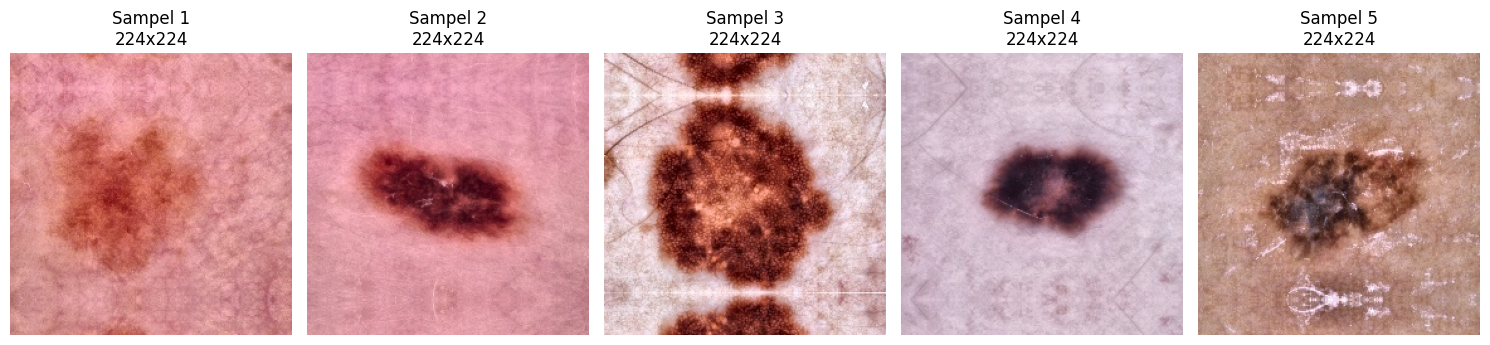

In [9]:
import cv2
import matplotlib.pyplot as plt
samples = df_final.head(5)

print("=== Pengecekan Dimensi 5 Gambar Teratas ===")
plt.figure(figsize=(15, 4))
for i, (index, row) in enumerate(samples.iterrows()):
    img_path = row['filepath']
    # Membaca gambar dari direktori offline preprocessing
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Mengekstrak dimensi gambar
    tinggi, lebar, _ = img.shape
    nama_file = img_path.split('/')[-1]
    # Mencetak info dimensi ke console
    print(f"[{nama_file}] -> Lebar: {lebar}, Tinggi: {tinggi}")
    # Menampilkan gambar pada plot
    plt.subplot(1, 5, i + 1)
    plt.title(f"Sampel {i+1}\n{lebar}x{tinggi}")
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

# split dataset

In [ ]:
# ==========================================
# TAHAP 4: PIPELINE DISTRIBUSI & OVERSAMPLING
# (70% TRAIN, 15% VALIDATION, 15% TEST)
# ==========================================

from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import resample
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 1. TRAIN-VALIDATION-TEST SPLIT (3 Bagian)
# ----------------------------------------------------
# Pemotongan 1: Ambil 70% untuk Train, sisa 30% untuk sementara
train_df, temp_df = train_test_split(
    df_final, 
    test_size=0.30, 
    random_state=42, 
    stratify=df_final['label']
)

# Pemotongan 2: Bagi rata sisa 30% menjadi 15% Val dan 15% Test
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_df['label']
)

print("=== RINGKASAN PEMBAGIAN DATA ===")
print(f"Jumlah data Train      : {len(train_df)}")
print(f"Jumlah data Validation : {len(val_df)}")
print(f"Jumlah data Test       : {len(test_df)}\n")

# ----------------------------------------------------
# 2. OVERSAMPLING SEMUA KELAS MINORITAS (3-KELAS)
# ----------------------------------------------------
# Cari jumlah kelas terbanyak, lalu upsample kelas lain agar seimbang
max_count = train_df['label'].value_counts().max()
dfs_balanced = []

for kelas in sorted(train_df['label'].unique()):
    df_kelas = train_df[train_df['label'] == kelas]
    if len(df_kelas) < max_count:
        df_kelas_upsampled = resample(
            df_kelas,
            replace=True,
            n_samples=max_count,
            random_state=42
        )
        dfs_balanced.append(df_kelas_upsampled)
    else:
        dfs_balanced.append(df_kelas)

# Menggabungkan data yang sudah seimbang
train_df_balanced = pd.concat(dfs_balanced)

# Mengacak urutan baris agar tidak menumpuk
train_df_balanced = train_df_balanced.sample(
    frac=1, random_state=42
).reset_index(drop=True)

print("=== DISTRIBUSI TRAIN SET (OVERSAMPLED) ===")
print(train_df_balanced['label'].value_counts().to_string())
print("\n==========================================\n")

# ----------------------------------------------------
# 3. KONFIGURASI AUGMENTASI TINGKAT LANJUT
# ----------------------------------------------------
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,             # Rotasi -15 s/d +15 derajat (Jurnal LA-CapsNet)
    brightness_range=[0.7, 1.3],   # Pengaturan kecerahan & kontras 0.7 - 1.3
    horizontal_flip=True,          # Flip horizontal acak
    vertical_flip=True,            # Flip vertikal acak
    zoom_range=0.15,               # Random crop / zoom
    width_shift_range=0.1,         # Shift horizontal
    height_shift_range=0.1,        # Shift vertikal
    fill_mode='reflect'         
)

# Validation dan Test HANYA di-preprocess, TIDAK di-augmentasi
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ----------------------------------------------------
# 4. PEMBUATAN BATCH DATA (RESIZE & DISTRIBUSI)
# ----------------------------------------------------
target_dim = (224, 224) 
batch_sz = 32            

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df_balanced, 
    x_col="filepath", 
    y_col="label",
    target_size=target_dim, 
    batch_size=batch_sz,
    class_mode="categorical",   # <-- 3-KELAS (one-hot encoding)
    shuffle=True
)

val_data = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, 
    x_col="filepath", 
    y_col="label",
    target_size=target_dim, 
    batch_size=batch_sz,
    class_mode="categorical",   # <-- 3-KELAS (one-hot encoding)
    shuffle=False
)

# Generator baru untuk evaluasi akhir (Blind Test)
test_data = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, 
    x_col="filepath", 
    y_col="label",
    target_size=target_dim, 
    batch_size=batch_sz,
    class_mode="categorical",   # <-- 3-KELAS (one-hot encoding)
    shuffle=False
)

## cek hasil

In [ ]:
# ==========================================
# CEK HASIL GENERATOR TAHAP 4 & SPESIFIKASI
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# 1. Mengambil 1 batch data dari generator
images, labels = next(iter(train_data))

# 2. Mengambil pemetaan nama kelas
class_labels = list(train_data.class_indices.keys())

# 3. Menampilkan Spesifikasi Teknis
print("=== SPESIFIKASI BATCH GAMBAR TAHAP 4 ===")
print(f"Bentuk Array Batch   : {images.shape} -> (Batch Size, Tinggi, Lebar, Channel RGB)")
print(f"Resolusi per Gambar  : {images.shape[1]} x {images.shape[2]} piksel")
print(f"Bentuk Label Batch   : {labels.shape} -> (Batch Size, Jumlah Kelas)")
print(f"Tipe Data Array      : {images.dtype}")
print(f"Rentang Nilai Piksel : {np.min(images):.2f} sampai {np.max(images):.2f} (Bukti preprocess_input ResNet50 aktif)")
print(f"Nama Kelas           : {class_labels}")
print("========================================\n")


# 4. Visualisasi 5 Gambar Pertama
fig, axes = plt.subplots(1, 5, figsize=(20, 5))


for i in range(5):

    ax = axes[i]

    # ===============================
    # BALIKKAN PREPROCESS RESNET50
    # AGAR GAMBAR NORMAL SAAT DITAMPILKAN
    # ===============================

    img_show = images[i].copy()

    # Tambahkan kembali mean ImageNet
    img_show = img_show + [103.939, 116.779, 123.68]

    # BGR -> RGB
    img_show = img_show[..., ::-1]

    # Batasi nilai
    img_show = np.clip(img_show, 0, 255)

    # ubah ke range matplotlib
    img_show = img_show / 255.0


    ax.imshow(img_show)


    # Label: argmax dari one-hot vector (karena class_mode='categorical')
    label_idx = int(np.argmax(labels[i]))
    nama_kelas = class_labels[label_idx]


    ax.set_title(
        f"Gambar {i+1}\nKelas: {nama_kelas}\n(Label: {label_idx})",
        fontsize=12
    )

    ax.axis('off')


plt.tight_layout()
plt.show()

# Modeling

In [ ]:
# ==========================================
# TAHAP 5: KONSTRUKSI ARSITEKTUR MODEL (MULTI-GPU) + TRIPLET ATTENTION
# ==========================================

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, GlobalMaxPooling2D,
    BatchNormalization, Dropout, Concatenate, Input,
    Conv2D, Activation, Lambda, Multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import tensorflow.keras.backend as K


# ---- TRIPLET ATTENTION MODULE ----

class ZPool(tf.keras.layers.Layer):
    """Z-Pool: Concat max dan average sepanjang axis tertentu."""
    def call(self, x):
        max_out = tf.reduce_max(x, axis=-1, keepdims=True)
        avg_out = tf.reduce_mean(x, axis=-1, keepdims=True)
        return tf.concat([max_out, avg_out], axis=-1)


class AttentionGate(tf.keras.layers.Layer):
    """Satu branch attention: ZPool -> Conv2D 3x3 -> Sigmoid."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.zpool = ZPool()
        self.conv = Conv2D(1, kernel_size=3, padding='same', use_bias=False)
        self.sigmoid = Activation('sigmoid')

    def call(self, x):
        out = self.zpool(x)
        out = self.conv(out)
        out = self.sigmoid(out)
        return out


class TripletAttention(tf.keras.layers.Layer):
    """
    Triplet Attention Module (WACV 2021)
    3 branch yang menangkap interaksi:
      - Branch 1: Channel x Height  (rotasi C<->H)
      - Branch 2: Channel x Width   (rotasi C<->W)
      - Branch 3: Height x Width    (spatial attention standar)
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.gate_ch = AttentionGate()   # Branch 1: C-H interaction
        self.gate_cw = AttentionGate()   # Branch 2: C-W interaction
        self.gate_hw = AttentionGate()   # Branch 3: H-W interaction (spatial)

    def call(self, x):
        # x shape: (B, H, W, C)

        # --- Branch 1: C x H ---
        # Permute: (B, H, W, C) -> (B, C, W, H)
        x_perm1 = tf.transpose(x, perm=[0, 3, 2, 1])
        attn1 = self.gate_ch(x_perm1)
        x_perm1 = x_perm1 * attn1
        # Kembalikan: (B, C, W, H) -> (B, H, W, C)
        x_perm1 = tf.transpose(x_perm1, perm=[0, 3, 2, 1])

        # --- Branch 2: C x W ---
        # Permute: (B, H, W, C) -> (B, H, C, W)
        x_perm2 = tf.transpose(x, perm=[0, 1, 3, 2])
        attn2 = self.gate_cw(x_perm2)
        x_perm2 = x_perm2 * attn2
        # Kembalikan: (B, H, C, W) -> (B, H, W, C)
        x_perm2 = tf.transpose(x_perm2, perm=[0, 1, 3, 2])

        # --- Branch 3: H x W (Spatial Attention standar) ---
        attn3 = self.gate_hw(x)
        x_branch3 = x * attn3

        # Gabungkan 3 branch (rata-rata)
        out = (x_perm1 + x_perm2 + x_branch3) / 3.0
        return out


# ---- BANGUN MODEL ----

# 1. MENGAKTIFKAN DUAL GPU (TESLA T4 x2)
strategy = tf.distribute.MirroredStrategy()
print(f"[INFO] Jumlah GPU Tersinkronisasi: {strategy.num_replicas_in_sync}")

# 2. Membangun model DI DALAM scope Multi-GPU
with strategy.scope():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    # =====================================================
    # ARSITEKTUR BARU: TripletAttention di conv4 (14x14)
    # Resolusi 14x14 jauh lebih efektif untuk attention
    # dibanding 7x7 di output akhir ResNet50
    # =====================================================
    
    # Ambil output dari conv4_block6 (14x14x1024)
    conv4_out = base_model.get_layer('conv4_block6_out').output
    
    # Terapkan Triplet Attention pada resolusi 14x14
    attended = TripletAttention(name='triplet_attention')(conv4_out)
    
    # Lanjutkan ke conv5 blocks menggunakan layer ResNet asli
    # Kita buat sub-model conv5 terpisah
    conv5_input = base_model.get_layer('conv5_block1_1_conv').input
    conv5_output = base_model.output  # (B, 7, 7, 2048)
    
    # Bangun model: Input -> conv1-conv4 -> TripletAttention -> conv5 -> Output
    # Karena conv5 sudah terhubung di graph ResNet, kita gunakan approach berbeda:
    # Ambil output akhir ResNet (7x7x2048) lalu tambahkan attention skip connection
    
    x_main = base_model.output  # (B, 7, 7, 2048) - fitur utama dari seluruh ResNet
    
    # Attention-weighted conv4 features (14x14x1024)
    # Pooling attended features ke ukuran yang sama
    attended_avg = GlobalAveragePooling2D(name='att_avg_pool')(attended)  # (B, 1024)
    
    # Main ResNet features (7x7x2048)
    avg_pool = GlobalAveragePooling2D()(x_main)   # (B, 2048)
    max_pool = GlobalMaxPooling2D()(x_main)        # (B, 2048)
    
    # Gabungkan: fitur ResNet + fitur attention-enhanced
    x = Concatenate()([avg_pool, max_pool, attended_avg])  # (B, 2048+2048+1024 = 5120)
    
    x = BatchNormalization()(x)

    x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.4)(x)

    # OUTPUT 3-KELAS: softmax untuk klasifikasi multi-kelas
    predictions = Dense(3, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)

print("Ringkasan Arsitektur Model (Multi-GPU + Triplet Attention @ Conv4 14x14 - 3 Kelas):")
model.summary()

# Training

In [ ]:
# ==========================================================
# TAHAP 6: PELATIHAN 2 FASE (MULTI-GPU, FOCAL, MICRO-UNFREEZE)
# ==========================================================

import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# ----------------------------------------------------
# 1. METRIK, FOCAL LOSS & CALLBACKS
# ----------------------------------------------------
# CategoricalFocalCrossentropy untuk klasifikasi 3-kelas
# Alpha 0.25 (default) cocok karena data sudah di-oversample seimbang
focal_loss = tf.keras.losses.CategoricalFocalCrossentropy(
    gamma=2.0, 
    alpha=0.25
)

metrics_list = [
    'accuracy',
    tf.keras.metrics.AUC(name='auc', multi_label=True, num_labels=3),
    tf.keras.metrics.AUC(curve='PR', name='pr_auc', multi_label=True, num_labels=3)
]

early_stop = EarlyStopping(
    monitor='val_pr_auc', 
    mode='max',
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    mode='min',
    factor=0.5, 
    patience=3, 
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='/kaggle/working/best_melanoma_model.keras',
    monitor='val_pr_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

callbacks_list = [lr_scheduler, early_stop, checkpoint]

# ----------------------------------------------------
# 2. FASE 1: WARM-UP (Melatih Custom Head saja)
# ----------------------------------------------------
base_model.trainable = False

with strategy.scope():
    model.compile(
        optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-4),
        loss=focal_loss,
        metrics=metrics_list
    )

print("[INFO] Memulai Fase 1: Warm-up Custom Head...")
start_time_f1 = time.time()

history_f1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10, 
    callbacks=callbacks_list
)

waktu_f1 = (time.time() - start_time_f1) / 60
print(f"Waktu Pelatihan Fase 1: {waktu_f1:.2f} menit\n")

# ----------------------------------------------------
# 3. FASE 2: MICRO-UNFREEZING (HANYA conv5_block3)
# ----------------------------------------------------
print("[INFO] Membuka conv5_block3, Kunci BatchNorm...")

with strategy.scope():
    base_model.trainable = True

    for layer in base_model.layers:
        # Kunci MATI seluruh layer BatchNormalization
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
            
        # Buka HANYA blok terdalam
        elif "conv5_block3" in layer.name:
            layer.trainable = True
            
        # Kunci sisanya
        else:
            layer.trainable = False

    # Learning Rate diturunkan perlahan
    model.compile(
        optimizer=AdamW(learning_rate=5e-6, weight_decay=1e-4),
        loss=focal_loss,
        metrics=metrics_list
    )

print("[INFO] Memulai Fase 2: Micro Fine-Tuning...")
start_time_f2 = time.time()

history_f2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30, 
    callbacks=callbacks_list
)

waktu_f2 = (time.time() - start_time_f2) / 60
print(f"Waktu Pelatihan Fase 2: {waktu_f2:.2f} menit\n")

# ----------------------------------------------------
# 4. EVALUASI BLIND TEST PADA DATA UJI (TEST SET)
# ----------------------------------------------------
print(f"[HASIL] Total Waktu Pelatihan: {waktu_f1+waktu_f2:.2f} menit")

# Menggunakan test_data yang sama sekali tidak disentuh saat training
print("\n[INFO] Menjalankan Evaluasi Blind Test...")
eval_results = model.evaluate(test_data)

final_loss = eval_results[0]
final_accuracy = eval_results[1]
final_auc = eval_results[2]
final_pr_auc = eval_results[3]

print(f"\n--- HASIL BLIND TEST AKHIR ---")
print(f"Akurasi Test : {final_accuracy * 100:.2f}%")
print(f"Loss Test    : {final_loss:.4f}")
print(f"AUC          : {final_auc:.4f}")
print(f"PR-AUC       : {final_pr_auc:.4f}")
print("------------------------------\n")

# Evaluasi

In [ ]:
# ==========================================
# TAHAP 7: EVALUASI MODEL & VISUALISASI (3-KELAS)
# ==========================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix
)

# ----------------------------------------------------
# 1. MENGGABUNGKAN RIWAYAT PELATIHAN (FASE 1 & FASE 2)
# ----------------------------------------------------
acc = history_f1.history['accuracy'] + history_f2.history['accuracy']
val_acc = (
    history_f1.history['val_accuracy'] + 
    history_f2.history['val_accuracy']
)
loss = history_f1.history['loss'] + history_f2.history['loss']
val_loss = (
    history_f1.history['val_loss'] + 
    history_f2.history['val_loss']
)

batas_fase = len(history_f1.history['accuracy']) - 1

# ----------------------------------------------------
# 2. VISUALISASI GRAFIK AKURASI DAN LOSS
# ----------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(
    x=batas_fase, color='red', linestyle='--', 
    label='Mulai Fine-Tuning'
)
plt.title('Pergerakan Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(
    x=batas_fase, color='red', linestyle='--', 
    label='Mulai Fine-Tuning'
)
plt.title('Pergerakan Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 3. EVALUASI VALIDATION SET (3-KELAS)
# ----------------------------------------------------
print("\n[INFO] Memuat model terbaik dari checkpoint fisik...")
# ============================================================
# FIX: Daftarkan semua custom layer SEBELUM load_model
# Keras perlu tahu class TripletAttention, ZPool, AttentionGate
# agar bisa membangun ulang model dari file .keras
# ============================================================
best_model = tf.keras.models.load_model(
    '/kaggle/working/best_melanoma_model.keras',
    custom_objects={
        'TripletAttention': TripletAttention,
        'AttentionGate': AttentionGate,
        'ZPool': ZPool,
    }
)

print("[INFO] Mengevaluasi Validation Set...")
val_data.reset() 

# Prediksi menghasilkan array (N, 3) — probabilitas setiap kelas
Y_pred_val = best_model.predict(
    val_data, steps=len(val_data), verbose=0
)

# Konversi probabilitas ke label kelas (argmax)
y_pred_classes_val = np.argmax(Y_pred_val, axis=1)
y_true_val = np.array(val_data.classes)
target_names = list(val_data.class_indices.keys())

# Pastikan panjang prediksi = panjang label asli
y_pred_classes_val = y_pred_classes_val[:len(y_true_val)]

print("=== CLASSIFICATION REPORT (VALIDATION SET) ===")
print(
    classification_report(
        y_true_val, y_pred_classes_val, target_names=target_names
    )
)

# ----------------------------------------------------
# 4. BLIND TEST & EVALUASI TEST SET
# ----------------------------------------------------
print("\n[INFO] Mengevaluasi Test Set (Blind Test)...")
test_data.reset()

Y_pred_test = best_model.predict(
    test_data, steps=len(test_data), verbose=0
)

y_pred_classes_test = np.argmax(Y_pred_test, axis=1)
y_true_test = np.array(test_data.classes)

# Pastikan panjang prediksi = panjang label asli
y_pred_classes_test = y_pred_classes_test[:len(y_true_test)]

print("=== CLASSIFICATION REPORT (TEST SET) ===")
print(
    classification_report(
        y_true_test, y_pred_classes_test, target_names=target_names
    )
)

# ----------------------------------------------------
# 5. VISUALISASI CONFUSION MATRIX BERDAMPINGAN (3x3)
# ----------------------------------------------------
cm_val = confusion_matrix(y_true_val, y_pred_classes_val)
cm_test = confusion_matrix(y_true_test, y_pred_classes_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Validation CM
sns.heatmap(
    cm_val, annot=True, fmt='d', cmap='Blues', 
    xticklabels=target_names, yticklabels=target_names,
    annot_kws={"size": 12}, ax=axes[0]
)
axes[0].set_title('Confusion Matrix - Validation Set', fontsize=14)
axes[0].set_ylabel('Label Aktual', fontsize=12)
axes[0].set_xlabel('Label Prediksi', fontsize=12)

# Plot Test CM
sns.heatmap(
    cm_test, annot=True, fmt='d', cmap='Greens', 
    xticklabels=target_names, yticklabels=target_names,
    annot_kws={"size": 12}, ax=axes[1]
)
axes[1].set_title('Confusion Matrix - Test Set', fontsize=14)
axes[1].set_ylabel('Label Aktual', fontsize=12)
axes[1].set_xlabel('Label Prediksi', fontsize=12)

plt.tight_layout()
plt.show()